In [199]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/logon.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/device.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/psychometric.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/http.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/readme.txt
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/license.txt
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/email.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/file.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/LDAP/2010-08.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/LDAP/2011-03.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/LDAP/2010-10.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/LDAP/2010-02.csv
/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/LDAP/2010-03.csv
/kaggle/input/datasets/revsyko/insider-threat-

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [201]:
dataset_path = "/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2/logon.csv"

df = pd.read_csv(dataset_path)

In [202]:
print(df.head())

                         id                 date     user       pc activity
0  {X1D9-S0ES98JV-5357PWMI}  01/02/2010 06:49:00  NGF0157  PC-6056    Logon
1  {G2B3-L6EJ61GT-2222RKSO}  01/02/2010 06:50:00  LRR0148  PC-4275    Logon
2  {U6Q3-U0WE70UA-3770UREL}  01/02/2010 06:53:04  LRR0148  PC-4124    Logon
3  {I0N5-R7NA26TG-6263KNGM}  01/02/2010 07:00:00  IRM0931  PC-7188    Logon
4  {D1S0-N6FH62BT-5398KANK}  01/02/2010 07:00:00  MOH0273  PC-6699    Logon


In [203]:
print("Dataset Shape:", df.shape)

Dataset Shape: (854859, 5)


## Column Description

The dataset contains the following columns:

- id → Unique event identifier
- date → Timestamp of the activity
- user → Employee/User ID
- pc → Computer ID
- activity → Login or Logout event

In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 854859 entries, 0 to 854858
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        854859 non-null  object
 1   date      854859 non-null  object
 2   user      854859 non-null  object
 3   pc        854859 non-null  object
 4   activity  854859 non-null  object
dtypes: object(5)
memory usage: 32.6+ MB


## Dataset Information

The logon dataset contains **854,859 employee login and logout records** with **5 columns**.

### Columns

- **id** – Unique event identifier
- **date** – Timestamp of the login/logout activity
- **user** – Employee/User identifier
- **pc** – Computer identifier
- **activity** – Type of activity (Logon or Logoff)

### Observations

- The dataset contains **no missing values**.
- All columns are currently stored as **object** data type.
- The `date` column will be converted to **datetime** during data cleaning.

In [205]:
df.describe(include='all')

,id,date,user,pc,activity
count,854859,854859,854859,854859,854859
unique,854859,338041,1000,1003,2
top,{T0U1-P7DT83QQ-7295ICZR},01/05/2010 08:00:00,WPR0368,PC-4124,Logon
freq,1,61,3470,25514,470591


## Statistical Summary

The statistical summary provides useful insights into the employee logon dataset.

### Observations

- The dataset contains **854,859 activity records**.
- Every record has a unique event ID.
- There are **1000 unique employees**.
- There are **1003 unique computers**.
- Only **two activity types** exist:
  - Logon
  - Logoff
- The most active employee is **WPR0368** with **3470 recorded activities**.
- The most frequently used computer is **PC-4124** with **25,514 activities**.
- Logon events occur more frequently than Logoff events.

In [206]:
df.isnull().sum()

id          0
date        0
user        0
pc          0
activity    0
dtype: int64

## Missing Value Analysis

Missing value analysis was performed to identify incomplete or corrupted records.

### Result

No missing values were found in any column.

### Conclusion

The dataset is complete and does not require missing value treatment before preprocessing.

In [207]:
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

Duplicate Records: 0


## Duplicate Record Analysis

Duplicate records were checked to ensure data quality.

### Result

No duplicate records were found.

### Conclusion

The dataset already contains unique records and no duplicate removal is necessary.

In [208]:
df.sample(10)

,id,date,user,pc,activity
780528,{G3V8-C5UT00TH-7557ITIB},03/29/2011 09:13:00,HSP0290,PC-2439,Logon
411139,{J4Z4-F1VW46JE-0475OFUL},08/15/2010 13:34:57,GZC0735,PC-8219,Logon
488054,{F1I4-U6JV10FV-2446ZIUW},09/28/2010 18:16:00,QCH0110,PC-7470,Logoff
59852,{B6I1-A8RL25SA-4328BRKB},02/03/2010 08:15:00,TLM0797,PC-4577,Logon
230375,{O3J6-B9NO24UU-2764AKBZ},05/05/2010 19:11:00,FDE0117,PC-1772,Logoff
768041,{A6P7-V0IO57WZ-3920KFWY},03/21/2011 17:24:00,FKK0055,PC-0435,Logoff
670112,{S7U7-B4UP70XX-6553XIJX},01/19/2011 17:49:00,CLS0296,PC-7973,Logoff
269791,{P2O2-U4CE14KY-3830MUIK},05/27/2010 06:24:57,JGT0221,PC-6610,Logoff
348038,{P1Z2-I2ZA37XO-3425QJKO},07/12/2010 07:32:00,USH0199,PC-3581,Logon
790757,{S9W1-R0KX82JX-7216EWLN},04/05/2011 01:41:15,RHO0732,PC-6232,Logon


## Sample Records

Random sample records were displayed to manually inspect the dataset and verify that the values appear consistent and realistic.

# Step 4: Data Cleaning

In this section, the dataset is prepared for further analysis by cleaning and transforming the data into appropriate formats.

In [209]:
print(df.dtypes)

id          object
date        object
user        object
pc          object
activity    object
dtype: object


## Observation

The `date` column is currently stored as an **object (string)**. Since it represents timestamps, it needs to be converted into the `datetime` data type for time-based analysis.

In [210]:
df['date'] = pd.to_datetime(df['date'])

In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 854859 entries, 0 to 854858
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   id        854859 non-null  object        
 1   date      854859 non-null  datetime64[ns]
 2   user      854859 non-null  object        
 3   pc        854859 non-null  object        
 4   activity  854859 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 32.6+ MB


## Observation

The `date` column has been successfully converted from the **object** data type to **datetime64[ns]**.

### Why was this conversion necessary?

The original dataset stored timestamps as plain text. Machine learning models cannot directly understand text-based dates.

Converting the column to the `datetime` format enables time-based analysis such as:

- Login hour analysis
- Daily login trends
- Monthly activity analysis
- Insider behavior monitoring

### Result

The dataset is now ready for temporal feature extraction.

In [212]:
df.head()

,id,date,user,pc,activity
0,{X1D9-S0ES98JV-5357PWMI},2010-01-02 06:49:00,NGF0157,PC-6056,Logon
1,{G2B3-L6EJ61GT-2222RKSO},2010-01-02 06:50:00,LRR0148,PC-4275,Logon
2,{U6Q3-U0WE70UA-3770UREL},2010-01-02 06:53:04,LRR0148,PC-4124,Logon
3,{I0N5-R7NA26TG-6263KNGM},2010-01-02 07:00:00,IRM0931,PC-7188,Logon
4,{D1S0-N6FH62BT-5398KANK},2010-01-02 07:00:00,MOH0273,PC-6699,Logon


## Verification of Date Conversion

The first five records were displayed after converting the `date` column.

### Observation

- The date format has changed from `MM/DD/YYYY HH:MM:SS` to the standard datetime format `YYYY-MM-DD HH:MM:SS`.
- All records remain unchanged except for the improved date representation.
- This confirms that the conversion was successful and no data was lost during preprocessing.

In [213]:
df.to_csv("cleaned_logon.csv", index=False)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


In [214]:
import os

os.listdir()

['.virtual_documents', 'feature_engineered_logon.csv', 'cleaned_logon.csv']

# Data Cleaning Summary

The following preprocessing tasks were completed successfully:

- Loaded the CERT Insider Threat `logon.csv` dataset.
- Explored the dataset structure and column information.
- Verified that there are no missing values.
- Verified that there are no duplicate records.
- Converted the `date` column from string (`object`) to `datetime`.
- Saved the cleaned dataset as `cleaned_logon.csv`.

The dataset is now ready for feature engineering and exploratory data analysis.

# Step 5: Feature Engineering

Feature engineering is the process of creating new meaningful attributes from existing data.

These engineered features help machine learning models identify behavioral patterns and detect insider threats more effectively.

In [215]:
df['login_hour'] = df['date'].dt.hour

df[['date','login_hour']].head()

,date,login_hour
0,2010-01-02 06:49:00,6
1,2010-01-02 06:50:00,6
2,2010-01-02 06:53:04,6
3,2010-01-02 07:00:00,7
4,2010-01-02 07:00:00,7


## Login Hour

The login hour was extracted from the timestamp.

This feature helps identify unusual login patterns such as late-night or early-morning access.

In [216]:
df['day'] = df['date'].dt.day

df[['date','day']].head()

,date,day
0,2010-01-02 06:49:00,2
1,2010-01-02 06:50:00,2
2,2010-01-02 06:53:04,2
3,2010-01-02 07:00:00,2
4,2010-01-02 07:00:00,2


## Day of Month

The day of the month was extracted from the timestamp.

This feature may help identify periodic behavioral patterns.

In [217]:
df['month'] = df['date'].dt.month

df[['date','month']].head()

,date,month
0,2010-01-02 06:49:00,1
1,2010-01-02 06:50:00,1
2,2010-01-02 06:53:04,1
3,2010-01-02 07:00:00,1
4,2010-01-02 07:00:00,1


## Month

The month was extracted from the timestamp.

This feature helps analyze long-term behavioral trends.

In [218]:
df['weekday'] = df['date'].dt.day_name()

df[['date','weekday']].head()

,date,weekday
0,2010-01-02 06:49:00,Saturday
1,2010-01-02 06:50:00,Saturday
2,2010-01-02 06:53:04,Saturday
3,2010-01-02 07:00:00,Saturday
4,2010-01-02 07:00:00,Saturday


## Weekday

The weekday was extracted from the timestamp.

Employee behavior often differs between weekdays and weekends, making this feature valuable for anomaly detection.

In [219]:
df['is_after_hours'] = df['login_hour'].apply(
    lambda x: 1 if x < 8 or x > 18 else 0
)

## After-Hours Login Feature

A new feature named **is_after_hours** was created.

### Logic

- 0 → Login during normal working hours (08:00–18:00)
- 1 → Login outside normal working hours

### Purpose

This feature will help identify unusual login behavior, which is an important indicator in insider threat detection systems.

In [220]:
print(df.columns)

Index(['id', 'date', 'user', 'pc', 'activity', 'login_hour', 'day', 'month',
       'weekday', 'is_after_hours'],
      dtype='object')


In [221]:
df["working_hours"] = df["is_after_hours"].map({
    0: "Working Hours",
    1: "After Hours"
})

In [222]:
df.to_csv("feature_engineered_logon.csv", index=False)

print("✅ Feature engineered dataset saved successfully!")

✅ Feature engineered dataset saved successfully!


# Feature Engineering Summary

The following features were created:

- Login Hour
- Day
- Month
- Weekday
- Working Hours Flag

These features enrich the dataset and prepare it for future machine learning models focused on insider threat detection.

# Step 6: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand employee behavior, identify activity patterns, and prepare the data for machine learning.

The following visualizations provide insights into login behavior and system usage.

activity
Logon     470591
Logoff    384268
Name: count, dtype: int64


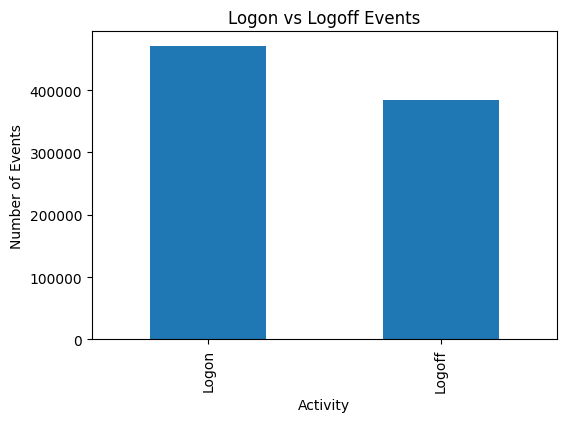

In [223]:
activity_counts = df['activity'].value_counts()

print(activity_counts)

activity_counts.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Logon vs Logoff Events")
plt.xlabel("Activity")
plt.ylabel("Number of Events")
plt.show()

## Activity Distribution

This chart compares the number of **Logon** and **Logoff** events.

### Purpose

It helps us understand whether login and logout activities are balanced across the organization.

This information is useful for identifying abnormal behavioral patterns in later stages.

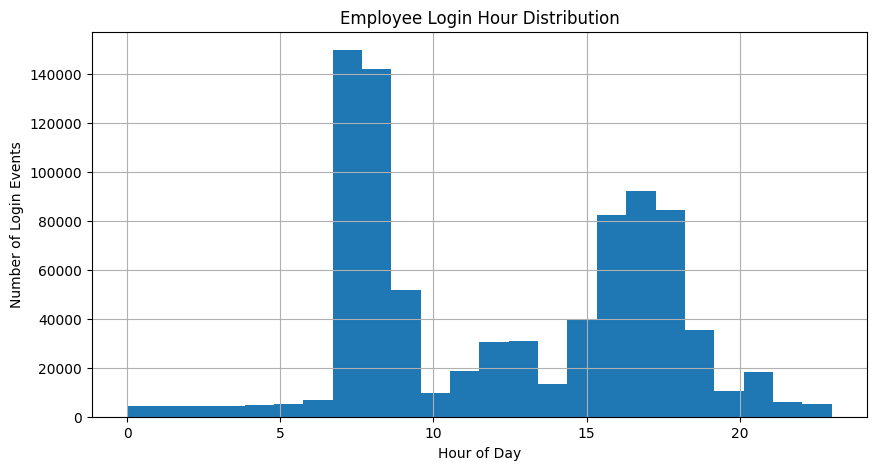

In [224]:
df['login_hour'].hist(
    bins=24,
    figsize=(10,5)
)

plt.title("Employee Login Hour Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Login Events")
plt.show()

## Login Hour Distribution

This histogram shows the distribution of employee login events throughout the day.

### Purpose

The graph helps identify:

- Peak login hours
- Low activity periods
- Potential after-hours access

This information is valuable for insider threat detection because unusual login times may indicate suspicious behavior.

working_hours
Working Hours    595555
After Hours      259304
Name: count, dtype: int64


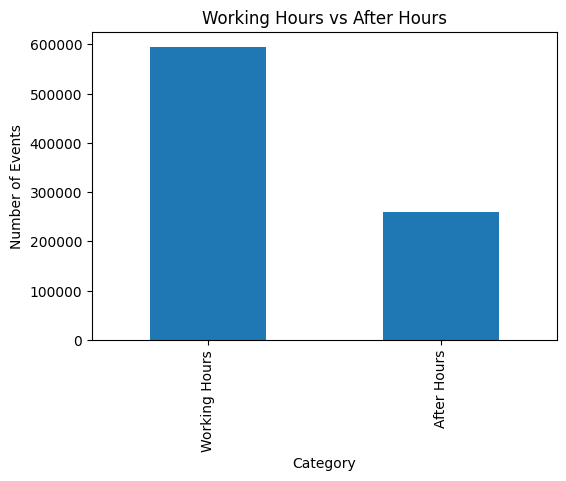

In [225]:
working_counts = df['working_hours'].value_counts()

print(working_counts)

working_counts.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Working Hours vs After Hours")
plt.xlabel("Category")
plt.ylabel("Number of Events")
plt.show()

## Working Hours Analysis

The login events were classified into:

- Working Hours
- After Hours

### Purpose

This visualization helps identify the proportion of employee activity occurring outside normal business hours.

Frequent after-hours access may require additional investigation.

user
WPR0368    3470
AJF0370    3267
CBB0365    3256
BAL0044    3146
IBB0359    3086
LBC0356    3053
EIS0041    3052
DMG0358    3038
HDS0367    3035
UIR0043    2860
Name: count, dtype: int64


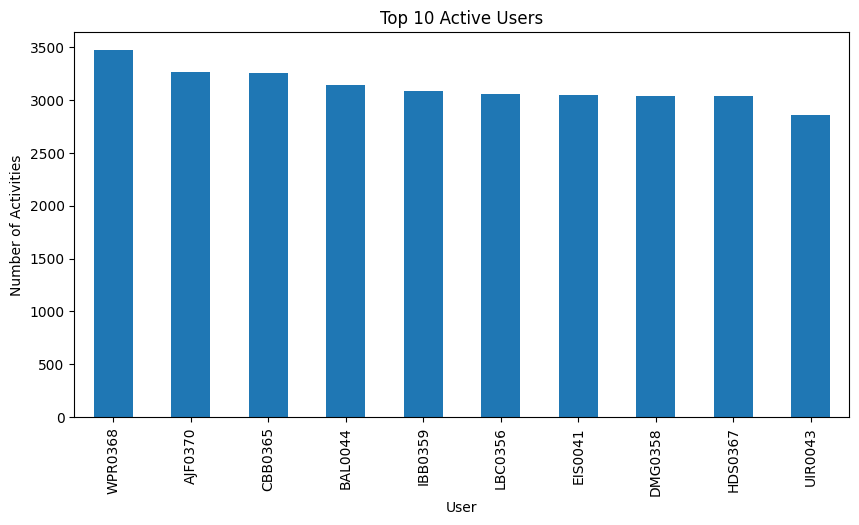

In [226]:
top_users = df['user'].value_counts().head(10)

print(top_users)

top_users.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Active Users")
plt.xlabel("User")
plt.ylabel("Number of Activities")
plt.show()

## Top Active Users

This chart identifies the employees with the highest recorded activity.

### Purpose

The most active users can be monitored further to understand whether their behavior follows normal working patterns.

pc
PC-4124    25514
PC-3847     4264
PC-0926     1657
PC-6184     1640
PC-0840     1545
PC-3819     1509
PC-7188     1487
PC-3842     1455
PC-7500     1443
PC-1313     1441
Name: count, dtype: int64


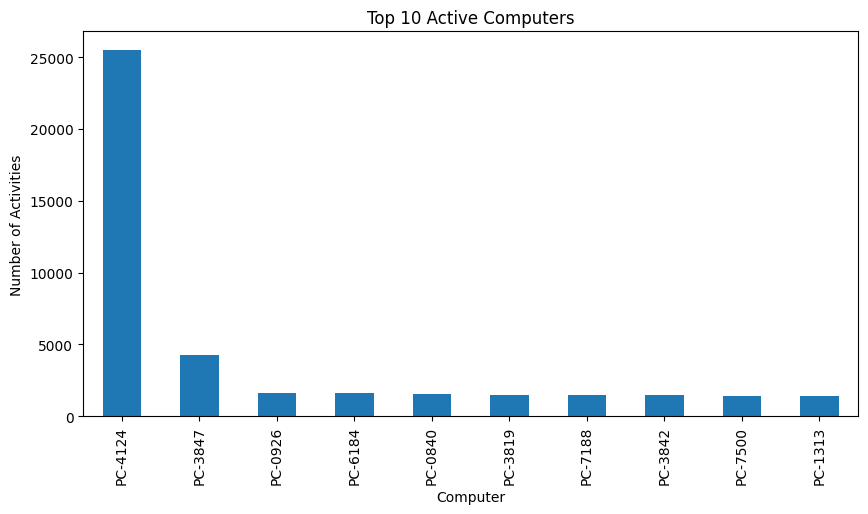

In [227]:
top_pc = df['pc'].value_counts().head(10)

print(top_pc)

top_pc.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Active Computers")
plt.xlabel("Computer")
plt.ylabel("Number of Activities")
plt.show()

## Top Active Computers

This visualization identifies the computers with the highest recorded activity.

### Purpose

High-activity systems can be prioritized for monitoring in future behavioral analysis.

login_hour
0       4243
1       4530
2       4433
3       4555
4       4600
5       5166
6       6749
7     149697
8     141848
9      51658
10      9495
11     18790
12     30403
13     30813
14     13547
15     39698
16     82514
17     92291
18     84498
19     35382
20     10367
21     18426
22      5932
23      5224
dtype: int64


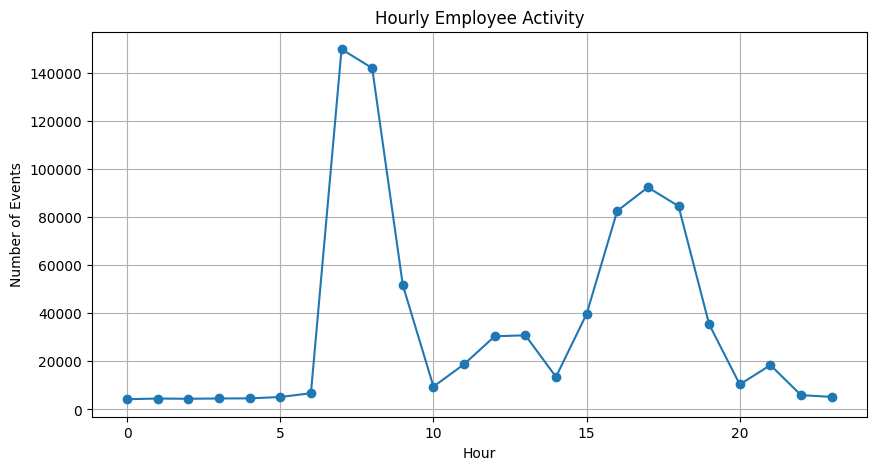

In [228]:
hourly_activity = df.groupby('login_hour').size()

print(hourly_activity)

hourly_activity.plot(
    marker='o',
    figsize=(10,5)
)

plt.title("Hourly Employee Activity")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.grid(True)
plt.show()

## Hourly Activity Trend

This visualization shows employee activity across different hours of the day.

### Purpose

The graph helps identify:

- Peak working hours
- Low activity periods
- Unusual login times

These insights are valuable for future anomaly detection models.

weekday
Monday       165624
Tuesday      171515
Wednesday    170796
Thursday     166703
Friday       160062
Saturday      10454
Sunday         9705
Name: count, dtype: int64


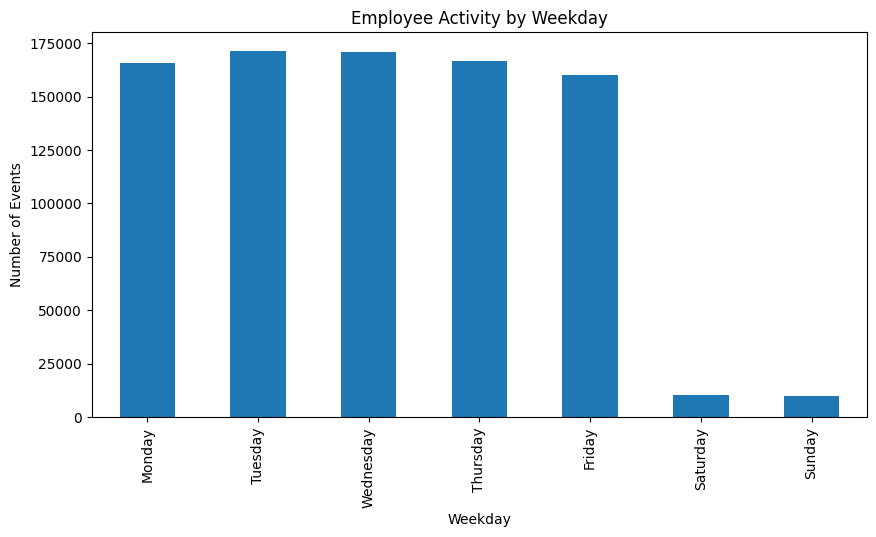

In [229]:
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_counts = df['weekday'].value_counts().reindex(weekday_order)

print(weekday_counts)

weekday_counts.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Employee Activity by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Events")
plt.show()

## Activity by Weekday

This visualization shows how employee activity varies throughout the week.

### Purpose

It helps identify normal working-day patterns and any unusual weekend activity.

# Exploratory Data Analysis Summary

The following insights were obtained from the logon dataset:

- Activity is dominated by Logon events.
- Employee activity peaks during standard office hours.
- A significant number of events occur after working hours.
- Some users and computers generate considerably more activity than others.
- Employee activity varies across weekdays.

These findings provide a strong foundation for anomaly detection and insider threat prediction in the next phase of the project.

# EDA Summary

The exploratory data analysis revealed several important behavioral patterns within the employee logon dataset.

## Key Findings

- Logon events occur more frequently than Logoff events.
- Most employee activity occurs during standard office hours.
- A considerable number of login events occur after working hours.
- Employee activity is highest during weekdays and significantly lower on weekends.
- A small number of users and computers generate a large proportion of activity.
- Peak login periods occur during the morning and late afternoon.

## Conclusion

These observations provide valuable insights into normal employee behavior and establish a strong baseline for future anomaly detection and insider threat prediction models.